# 5. Random forests and extra trees

**Question: does extra randomisation help when the features are redundant and the
positive class is rare?**

Random forests and extra trees differ in one place: how a split point is chosen. A random
forest searches for the best threshold within a sampled feature subset; extra trees pick
the threshold at random. The extra randomisation lowers variance and costs bias.

With 171 correlated sensor aggregates and ~1.7% positives, it is not obvious which side
of that trade wins. Both families also handle the missingness question differently from
the linear models — the imputer is still there, but a tree can isolate the indicator
column cheaply.

Regularization here is structural: tree count, depth, minimum leaf size and the feature
subsample.

> **The objective.** Every number in this notebook is judged against
> `J = 10·FP + 500·FN`. A false positive is an unnecessary inspection; a false
> negative is a truck that fails in service. Missing one failure costs as much
> as fifty needless inspections, and that ratio is what makes the modelling
> choices here matter.

In [1]:
from pathlib import Path

import pandas as pd

from scania_aps.data import TEST_FILENAME, TRAIN_FILENAME, read_raw_csv
from scania_aps.plotting import apply_house_style

ROOT = Path.cwd().resolve()
if ROOT.name == "experiments":
    ROOT = ROOT.parent
TRAIN = ROOT / "data" / "raw" / TRAIN_FILENAME
TEST = ROOT / "data" / "raw" / TEST_FILENAME
ARTIFACTS = ROOT / "artifacts"
assert TRAIN.exists() and TEST.exists(), "Run: poetry run scania-aps download"

apply_house_style()

train = read_raw_csv(TRAIN)
test = read_raw_csv(TEST)

pd.DataFrame(
    {
        "trucks": [len(train.y), len(test.y)],
        "features": [train.X.shape[1], test.X.shape[1]],
        "failures": [int(train.y.sum()), int(test.y.sum())],
        "failure_rate": [train.y.mean(), test.y.mean()],
    },
    index=["training set", "official test set"],
)

,trucks,features,failures,failure_rate
training set,60000,170,1000,0.016667
official test set,16000,170,375,0.023438


In [2]:
from scania_aps.costs import optimize_score_threshold
from scania_aps.metrics import evaluate_scores
from scania_aps.models.trees import TreeEnsembleConfig, build_tree_pipeline
from scania_aps.scoring import positive_class_scores
from scania_aps.split import development_split

split = development_split(train.X, train.y)

configurations = [
    TreeEnsembleConfig(
        kind=kind,
        n_estimators=400,
        max_depth=depth,
        min_samples_leaf=leaf,
        positive_class_weight=weight,
    )
    for kind in ("random_forest", "extra_trees")
    for depth in (None, 12)
    for leaf in (1, 10)
    for weight in (None, 20.0)
]

rows = []
for config in configurations:
    pipeline = build_tree_pipeline(config).fit(split.X_fit, split.y_fit)
    scores = positive_class_scores(pipeline, split.X_tune)
    chosen = optimize_score_threshold(split.y_tune.to_numpy(), scores.values)
    evaluation = evaluate_scores(
        split.y_tune.to_numpy(), scores.values, chosen.threshold, score_kind=scores.kind
    )
    rows.append(
        {
            "kind": config.kind,
            "max_depth": config.max_depth,
            "min_samples_leaf": config.min_samples_leaf,
            "class_weight": config.positive_class_weight,
            "threshold": chosen.threshold,
            "tune_cost": evaluation.total_cost,
            "false_negatives": evaluation.false_negatives,
            "false_positives": evaluation.false_positives,
            "pr_auc": evaluation.pr_auc,
        }
    )

tree_results = pd.DataFrame(rows).sort_values("tune_cost")
tree_results

,kind,max_depth,min_samples_leaf,class_weight,threshold,tune_cost,false_negatives,false_positives,pr_auc
0,random_forest,NaN,1,NaN,0.131250,4620.0,6,162,0.879846
1,random_forest,NaN,1,20.0,0.123750,4630.0,5,213,0.853805
4,random_forest,12.0,1,NaN,0.103550,4920.0,6,192,0.875047
5,random_forest,12.0,1,20.0,0.171485,4990.0,5,249,0.790432
9,extra_trees,NaN,1,20.0,0.096250,5040.0,6,204,0.852215
6,random_forest,12.0,10,NaN,0.117154,5110.0,6,211,0.831620
8,extra_trees,NaN,1,NaN,0.086250,5130.0,6,213,0.872999
2,random_forest,NaN,10,NaN,0.113686,5210.0,6,221,0.840076
3,random_forest,NaN,10,20.0,0.281890,5320.0,5,282,0.818135
7,random_forest,12.0,10,20.0,0.263105,5570.0,5,307,0.811010


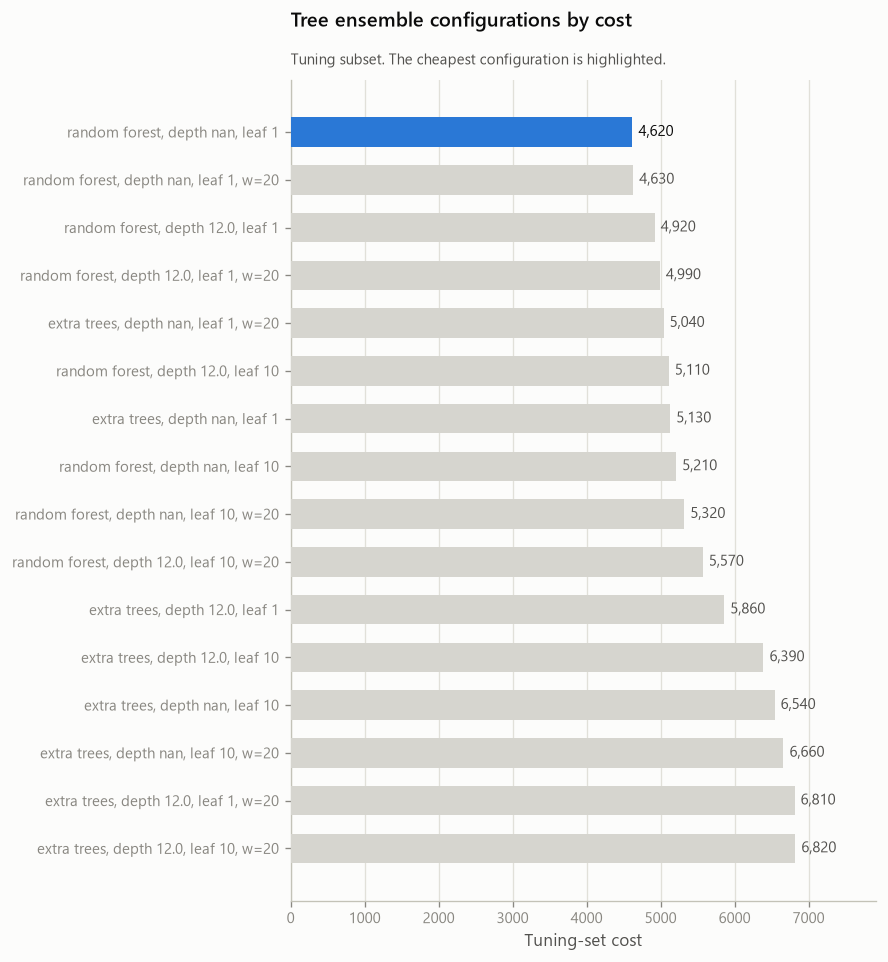

In [3]:
from scania_aps.plotting import emphasis_bars

labels = [
    f"{r.kind.replace('_', ' ')}, depth {r.max_depth or 'none'}, leaf {r.min_samples_leaf}"
    + (f", w={r.class_weight:.0f}" if pd.notna(r.class_weight) else "")
    for r in tree_results.itertuples()
]

fig, ax = emphasis_bars(
    labels,
    [float(v) for v in tree_results["tune_cost"].to_numpy()],
    title="Tree ensemble configurations by cost",
    subtitle="Tuning subset. The cheapest configuration is highlighted.",
    xlabel="Tuning-set cost",
)

## Where the two families separate

Aggregating over the structural settings isolates the one difference that defines the
two families.

In [4]:
summary = (
    tree_results.groupby("kind")
    .agg(
        best_cost=("tune_cost", "min"),
        median_cost=("tune_cost", "median"),
        best_recall_cost=("tune_cost", "min"),
    )
    .drop(columns="best_recall_cost")
)
summary["median_cost_gap"] = summary["median_cost"] - summary["median_cost"].min()
summary

,best_cost,median_cost,median_cost_gap
kind,,,
extra_trees,5040.0,6465.0,1415.0
random_forest,4620.0,5050.0,0.0


### Reading the result

Compare `best_cost` between the two rows: that is the fair head-to-head, each family at
its own best structural setting. `median_cost` says something different — how much the
family depends on getting those settings right. A family with a low median is forgiving;
one with a low best and a high median needs tuning to be worth it.

Deep, unpruned trees with `min_samples_leaf=1` memorise the majority class here; the
cost column penalises that directly, which is why leaf size is in the sweep at all.

**Next:** [06 — gradient boosting](06_gradient_boosting.ipynb), where regularization
becomes explicit rather than structural.